In [1]:
import torch 

torch.cuda.is_available()

True

### Reading raw job logs + initial analysis

In [1]:
import os
import glob
import time
import polars as pl

# 1. Direct path setup
RAW_DIR = "/media/storage0/allison/BatchSystem-2025"

# Find all 32 partition files directly in RAW_DIR
valid_paths = sorted(glob.glob(os.path.join(RAW_DIR, "fife_raw_part_*.parquet")))
print(f"Found {len(valid_paths)} Parquet partition files.")
assert valid_paths, f"No files found in {RAW_DIR} matching 'fife_raw_part_*.parquet'!"

# Calculate dataset size on disk
total_gb = sum(os.path.getsize(p) for p in valid_paths) / 1e9
print(f"Total dataset size on disk: {total_gb:.2f} GB across {len(valid_paths)} files.")

# 2. Columns to extract
NEED = [
    "ExitCode","ExitSignal","JobStatus","RemoveReason","LastHoldReason","LastHoldReasonCode",
    "NumJobStarts","QDate","JobStartDate","JobCurrentStartDate","JobCurrentStartExecutingDate",
    "CompletionDate","RemoteWallClockTime","x509UserProxyExpiration","Owner","AccountingGroup",
    "Group","POMS4_CAMPAIGN_ID","POMS4_CAMPAIGN_NAME","POMS4_CAMPAIGN_STAGE_NAME",
    "POMS4_CAMPAIGN_STAGE_ID","POMS4_CAMPAIGN_TYPE","POMS4_TEST_LAUNCH","Jobsub_Group",
    "SingularityImage","Blacklist_Sites","RequestCpus","RequestDisk","RequestMemory","RequestSlots",
    "CpusProvisioned","DiskProvisioned","MemoryProvisioned","ExecutableSize","TransferInputSizeMB",
    "JOB_EXPECTED_MAX_LIFETIME","TotalSubmitProcs","MATCH_EXP_JOB_GLIDEIN_Site","MATCH_GLIDEIN_Entry_Name",
    "MATCH_GLIDEIN_SiteWMS_Queue","MachineAttrGLIDEIN_ResourceName0","MachineAttrCpus0","LastRemoteHost",
    "MATCH_EXP_JOB_Site","ClusterId",
]

# Quick schema check from the first partition (instant, no data read)
schema_sample = pl.read_parquet_schema(valid_paths[0])
have = [c for c in NEED if c in schema_sample.names()]
missing = [c for c in NEED if c not in schema_sample.names()]
if missing:
    print("Columns in NEED not present in raw dataset:", missing)

# 3. Create LazyFrame across all 32 partitions
try:
    lf = pl.scan_parquet(valid_paths, missing_columns="insert")
except TypeError:
    lf = pl.scan_parquet(valid_paths, allow_missing_columns=True)

# Select only needed columns (Projection Pushdown saves massive amounts of RAM/CPU)
lf = lf.select(have)

if "AccountingGroup" in have:
    lf = lf.with_columns(pl.col("AccountingGroup").str.split(".").list.first().alias("Group"))
    if "Group" not in have:
        have.append("Group")

schema = lf.collect_schema()

# Timestamp normalization helper
def to_sec(col):
    if isinstance(schema[col], pl.Datetime):
        return pl.col(col).dt.epoch(time_unit="s").cast(pl.Float64)
    v = pl.col(col).cast(pl.Float64, strict=False)
    return (pl.when(v > 1e17).then(v / 1e9)
              .when(v > 1e14).then(v / 1e6)
              .when(v > 1e11).then(v / 1e3)
              .otherwise(v))

qcol = next((c for c in ["QDate_ms","QDate"] if c in have), None)
scol = next((c for c in ["JobStartDate_ms","JobStartDate","JobCurrentStartDate_ms","JobCurrentStartExecutingDate"] if c in have), None)

# Labeling & Feature Logic
EXIT_SUB=[9,65,90,91,124,126,127,130,131,137]; EXIT_HW=[129,143]
SIG_SUB=[2,3,9]; SIG_HW=[1,15]; HOLD_APP=[3,6,16]; HOLD_SUB=[1,4,7,8,12,13,26,32,33,34,35]

ec, es, js = pl.col("ExitCode"), pl.col("ExitSignal"), pl.col("JobStatus")
lhr = pl.col("LastHoldReasonCode") if "LastHoldReasonCode" in have else pl.lit(None, dtype=pl.Int64)
rr  = pl.col("RemoveReason").fill_null("") if "RemoveReason" in have else pl.lit("")

rr_lower = pl.col("rr").str.to_lowercase()

rr_lower = rr.str.to_lowercase()

import polars as pl

rr_lower = rr.str.to_lowercase()

import polars as pl

# Case-insensitive removal reason
rr_lower = rr.str.to_lowercase()

ftype = (
    # 1. VOLUNTARY USER CANCELLATIONS -> -2 (Not a technical failure)
    pl.when(
        (js == 3)
        & (
            rr_lower.str.contains("condor_rm")
            | rr_lower.str.contains("by user")
            | rr_lower.str.contains("user remove")
        )
    )
    .then(-2)
    # 2. CLEAN SUCCESS -> -1 (ExitCode 0, no signal, not removed)
    .when((ec == 0) & es.is_null() & (js != 3))
    .then(-1)
    # 3. SIGNALS (Rule 2)
    .when(es.is_not_null())
    .then(
        pl.when(es.is_in(SIG_SUB))
        .then(2)
        .when(es.is_in(SIG_HW))
        .then(1)
        .otherwise(0)  # Unlisted signals -> Application Failure
    )
    # 4. NON-ZERO EXIT CODES (Rule 3)
    .when(ec.is_not_null() & (ec != 0))
    .then(
        pl.when(ec.is_in(EXIT_SUB))
        .then(2)
        .when(ec.is_in(EXIT_HW))
        .then(1)
        .otherwise(0)  # Unlisted exit codes -> Application Failure
    )
    # 5. SYSTEM-ENFORCED REMOVALS (Rule 4: JobStatus == 3 non-user)
    .when(js == 3)
    .then(
        pl.when(
            rr_lower.str.contains("exceeding job limits")
            | rr_lower.str.contains("opportunistic")
        )
        .then(2)  # Submission Failure
        .when(
            rr_lower.str.contains("otherjobremoverequirements")
            | rr_lower.str.contains("node error: dag node")
            | rr_lower.str.contains("held 14 days")
            | rr_lower.str.contains("periodicremove")
        )
        .then(0)  # Application Failure
        .when(rr_lower.str.contains("jobrouter"))
        .then(1)  # Hardware Failure
        .otherwise(1)  # System removals with unknown reason default to Hardware
    )
    # 6. HOLD REASONS (Rule 5: For remaining unremoved held jobs)
    .when(lhr.is_in(HOLD_SUB))
    .then(2)
    .when(lhr.is_in(HOLD_APP))
    .then(0)
    # Fallback to Success
    .otherwise(-1)
).cast(pl.Int8)

wait = (
    (to_sec(scol) - to_sec(qcol)) if (scol and qcol) else pl.lit(None, dtype=pl.Float64)
)

# Column indicators
lf = lf.with_columns(
    [
        ftype.alias("fault_type"),
        (ftype >= 0).cast(pl.Int8).alias("Failed"),  # Genuine technical failures only
        (ftype == -2).cast(pl.Int8).alias("UserCancelled"),  # Voluntary user aborts
        (ftype == -1).cast(pl.Int8).alias("Success"),  # Clean executions
        (ftype == 1).cast(pl.Int8).alias("hw_fault"),  # Hardware faults
        pl.when(wait > 0).then(wait).otherwise(None).alias("wait_s"),
    ]
)

# Derive binary failure label
failed = (ftype >= 0).cast(pl.Int8)

wait = (to_sec(scol) - to_sec(qcol)) if (scol and qcol) else pl.lit(None, dtype=pl.Float64)

lf = lf.with_columns([
    failed.alias("Failed"), 
    ftype.alias("fault_type"),
    pl.when(wait > 0).then(wait).otherwise(None).alias("wait_s")
]).with_columns((pl.col("fault_type") == 1).cast(pl.Int8).alias("hw_fault"))

# Filter stragglers (jobs queued before the data window (2025-02-01 00:00 UTC))
QMIN_S = 1738368000
if qcol:
    lf = lf.filter(to_sec(qcol) >= QMIN_S)

print("Lazy execution plan initialized successfully!")

Found 32 Parquet partition files.
Total dataset size on disk: 1.77 GB across 32 files.
Lazy execution plan initialized successfully!


In [3]:
import time
import polars as pl
import datetime as dt

# 1. Memory-safe collector with full fallback for unsupported streaming operations
def sc(frame):
    try:
        return frame.collect(engine="streaming")
    except TypeError:
        return frame.collect(streaming=True)
    except Exception:
        return frame.collect()  # Safe fallback if streaming engine hits a ComputeError
    
t = time.time()

# Aggregate all outcome buckets in a single pass
agg = sc(
    lf.select(
        [
            pl.len().alias("n_total"),
            pl.col("Success").sum().alias("n_success"),
            pl.col("UserCancelled").sum().alias("n_user_cancelled"),
            pl.col("Failed").sum().alias("n_genuine_failed"),
            (pl.col("fault_type") == 0).sum().alias("n_app"),
            (pl.col("fault_type") == 1).sum().alias("n_hw"),
            (pl.col("fault_type") == 2).sum().alias("n_sub"),
        ]
    )
)

n_total = agg["n_total"][0]
n_success = agg["n_success"][0]
n_user_cancelled = agg["n_user_cancelled"][0]
n_failed = agg["n_genuine_failed"][0]

n_app = agg["n_app"][0]
n_hw = agg["n_hw"][0]
n_sub = agg["n_sub"][0]
n_payload = n_app + n_sub

# Rates relative to all submitted jobs
pct_success = (n_success / n_total) * 100
pct_user_cancelled = (n_user_cancelled / n_total) * 100
fail_rate_overall = (n_failed / n_total) * 100

# Failure rate among completed/non-cancelled jobs
n_completed = n_total - n_user_cancelled
fail_rate_completed = (n_failed / n_completed) * 100

# Fault proportions among genuine failures
pct_payload_of_fail = (n_payload / n_failed) * 100 if n_failed > 0 else 0.0
pct_hw_of_fail = (n_hw / n_failed) * 100 if n_failed > 0 else 0.0

print(f"DATASET")
print(f"Total Submitted Jobs       : {n_total:,}")
print(f"  ├─ Clean Successes       : {n_success:,} ({pct_success:.2f}%)")
print(
    f"  ├─ Voluntary User Removals: {n_user_cancelled:,} ({pct_user_cancelled:.2f}%)"
)
print(
    f"  └─ Genuine Failures      : {n_failed:,} ({fail_rate_overall:.2f}% of total)"
)
print("-" * 65)
print(
    f"Failure Rate (excluding user cancellations) : {fail_rate_completed:.2f}%"
)
print("-" * 65)
print("FAULT ATTRIBUTION (Genuine Failures Only):")
print(
    f"  ├─ Payload Faults (App + Sub) : {n_payload:,} ({pct_payload_of_fail:.1f}%)"
)
print(
    f"  │    ├─ Application Faults    : {n_app:,} ({n_app/n_failed*100:.1f}%)"
)
print(
    f"  │    └─ Submission Faults     : {n_sub:,} ({n_sub/n_failed*100:.1f}%)"
)
print(
    f"  └─ Hardware Faults            : {n_hw:,} ({pct_hw_of_fail:.1f}%)"
)
print("=" * 65)

DATASET
Total Submitted Jobs       : 64,025,075
  ├─ Clean Successes       : 46,999,792 (73.41%)
  ├─ Voluntary User Removals: 8,035,800 (12.55%)
  └─ Genuine Failures      : 8,989,483 (14.04% of total)
-----------------------------------------------------------------
Failure Rate (excluding user cancellations) : 16.06%
-----------------------------------------------------------------
FAULT ATTRIBUTION (Genuine Failures Only):
  ├─ Payload Faults (App + Sub) : 8,238,735 (91.6%)
  │    ├─ Application Faults    : 7,586,182 (84.4%)
  │    └─ Submission Faults     : 652,553 (7.3%)
  └─ Hardware Faults            : 750,748 (8.4%)


Computing wait quantiles

In [4]:
qs = [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
wq = sc(
    lf.select(
        [pl.col("wait_s").quantile(q).alias(f"p{int(q*100)}") for q in qs]
        + [pl.col("wait_s").median().alias("median")]
    )
).to_dicts()[0]

formatted_wq = {k: (round(v) if v is not None else None) for k, v in wq.items()}
median_val = wq.get("median")
median_min = round(median_val / 60, 1) if median_val is not None else None

print("wait_s (s):", formatted_wq, " median(min):", median_min)

wait_s (s): {'p10': 40, 'p25': 320, 'p50': 1548, 'p75': 6858, 'p90': 23459, 'p99': 237083, 'median': 1548}  median(min): 25.8


Dataset characterization (streaming: timeframe / users / sites / groups / batches)

In [5]:
GROUPCOL = "Group" if "Group" in have or "AccountingGroup" in have else None  
SITECOL ="MATCH_EXP_JOB_GLIDEIN_Site"

# 2. Time frame calculation with qcol safeguard
if qcol and qcol in have:
    _sch = lf.collect_schema()
    def _sec(col):
        if isinstance(_sch[col], pl.Datetime):
            return pl.col(col).dt.epoch(time_unit="s").cast(pl.Float64)
        v = pl.col(col).cast(pl.Float64, strict=False)
        return (pl.when(v > 1e17).then(v / 1e9)
                  .when(v > 1e14).then(v / 1e6)
                  .when(v > 1e11).then(v / 1e3)
                  .otherwise(v))

    tf = sc(lf.select([_sec(qcol).min().alias("start"), _sec(qcol).max().alias("end")]))
    s0, s1 = tf["start"][0], tf["end"][0]
else:
    s0, s1 = None, None

def fmt(s):
    try:
        return dt.datetime.fromtimestamp(s, dt.timezone.utc).strftime("%Y-%m-%d %H:%M")
    except (ValueError, OverflowError, TypeError, OSError):
        return f"raw={s}"

if s0 is not None and s1 is not None:
    print(f"time frame (submit): {fmt(s0)}  ->  {fmt(s1)}   ({(s1 - s0) / 86400:.0f} days)")
else:
    print("time frame: n/a")

# 3. Cardinalities
card = {}
for name, col in [("users", "Owner"), ("sites", SITECOL), ("groups", GROUPCOL),
                  ("batches", "ClusterId"), ("campaigns", "POMS4_CAMPAIGN_ID"),
                  ("images", "SingularityImage")]:
    if col and col in have:
        card[name] = sc(lf.select(pl.col(col).n_unique())).item()
print("distinct:", card)

time frame (submit): 2025-02-01 00:00  ->  2025-08-31 18:59   (212 days)
distinct: {'users': 395, 'sites': 44, 'groups': 27, 'batches': 20065140, 'campaigns': 684, 'images': 25}


### Feature evaluation

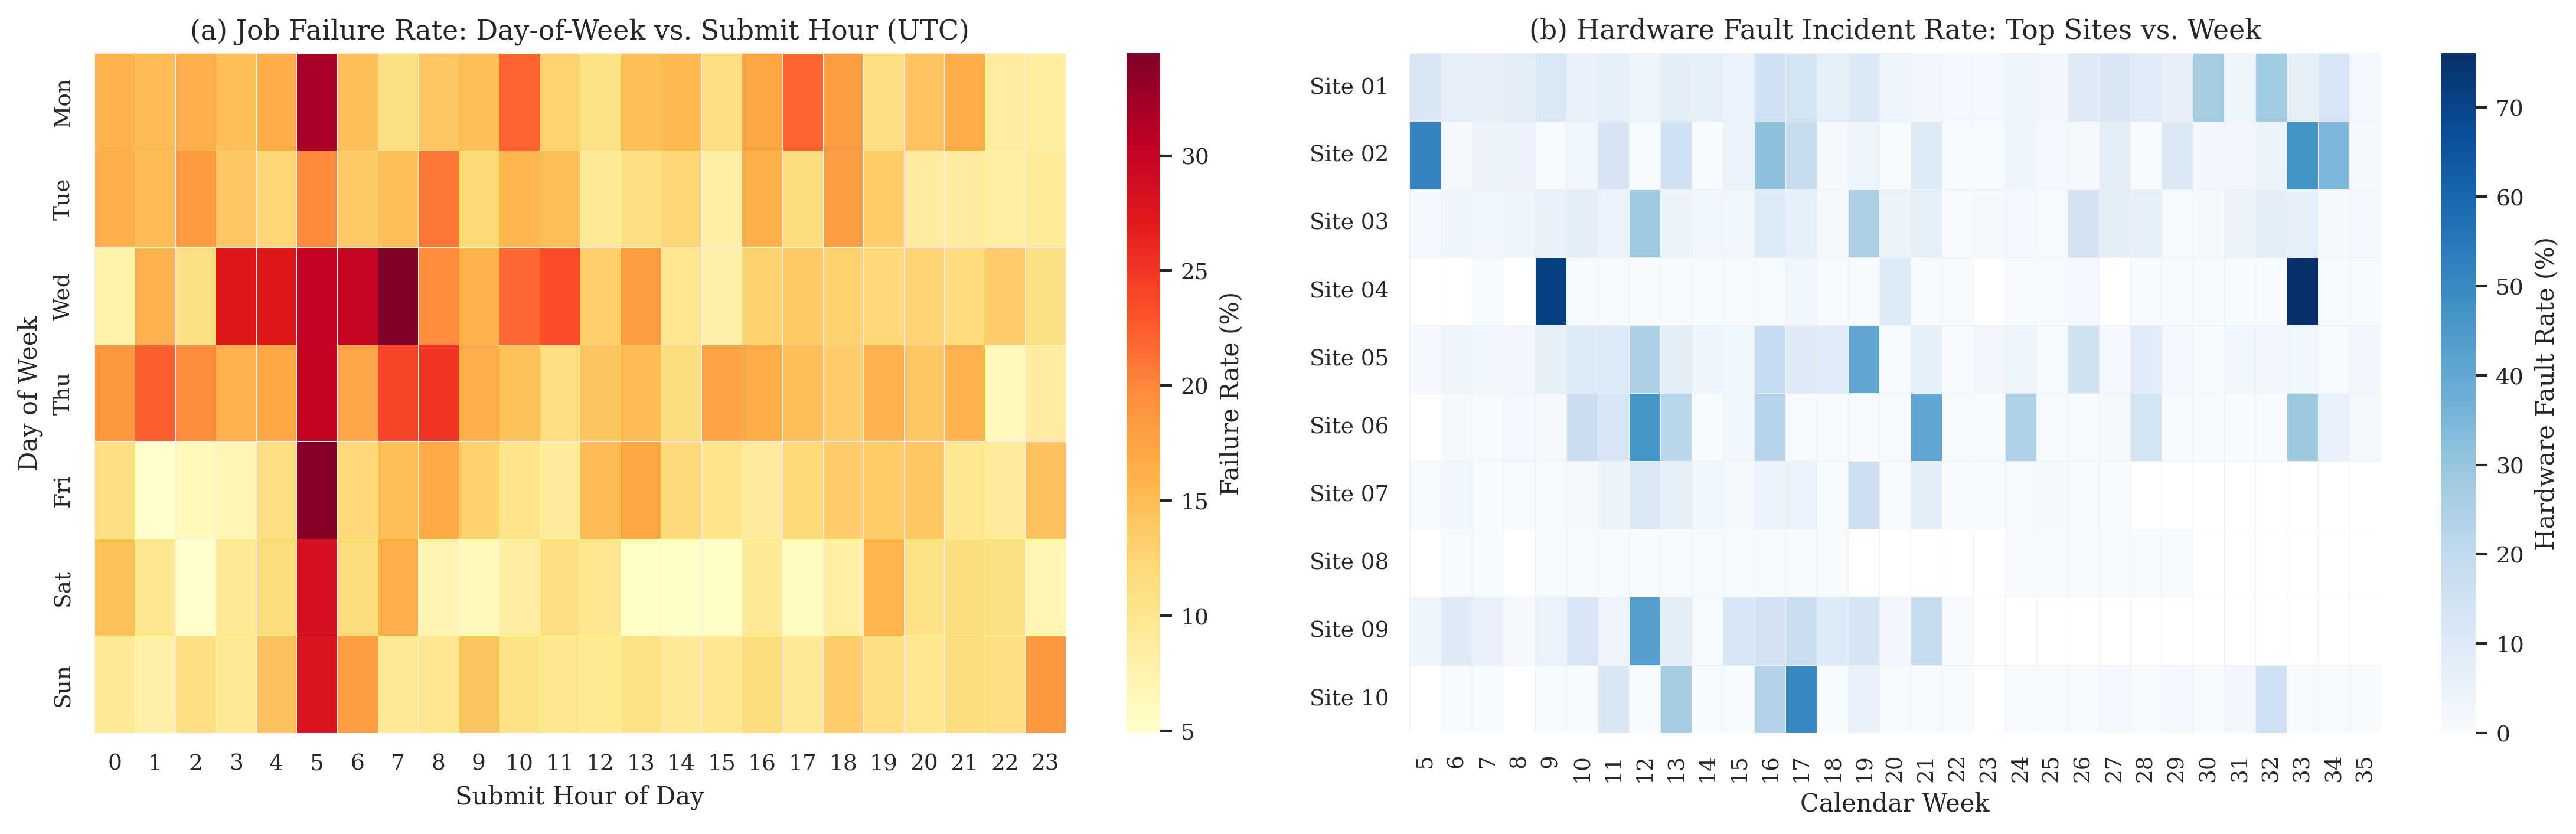

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

sns.set_theme(style="white", context="paper", font="serif")

SITECOL = "MATCH_EXP_JOB_GLIDEIN_Site"
qcol = "QDate"

plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

PAL = {"fail": "#D55E00", "hw": "#0072B2", "jobs": "#009E73"}

def sc(f):
    try:
        return f.collect(engine="streaming")
    except TypeError:
        return f.collect(streaming=True)


_sch = lf.collect_schema()


def _sec(c):
    if isinstance(_sch[c], pl.Datetime):
        return pl.col(c).dt.epoch("s").cast(pl.Float64)
    v = pl.col(c).cast(pl.Float64, strict=False)
    return (
        pl.when(v > 1e17)
        .then(v / 1e9)
        .when(v > 1e14)
        .then(v / 1e6)
        .when(v > 1e11)
        .then(v / 1e3)
        .otherwise(v)
    )


# Extract temporal components
dtq = pl.from_epoch(_sec(qcol).cast(pl.Int64), time_unit="s")
lfz = lf.with_columns(
    [
        dtq.dt.hour().alias("hour"),
        dtq.dt.weekday().alias("dow"),
        dtq.dt.week().alias("week"),
    ]
)

hd_df = sc(
    lfz.group_by(["dow", "hour"]).agg(
        (pl.col("Failed").mean() * 100.0).alias("fail_rate")
    )
).to_pandas()

hd_pivot = hd_df.pivot(
    index="dow", columns="hour", values="fail_rate"
).sort_index()

# Map integer DOW (1-7) to abbreviated day names
dow_map = {
    1: "Mon",
    2: "Tue",
    3: "Wed",
    4: "Thu",
    5: "Fri",
    6: "Sat",
    7: "Sun",
}
hd_pivot.index = [dow_map.get(i, i) for i in hd_pivot.index]

# Extract top 10 sites by total job volume
tops_raw = sc(
    lf.filter(pl.col(SITECOL).is_not_null())
    .group_by(SITECOL)
    .len()
    .sort("len", descending=True)
    .head(10)
)[SITECOL].to_list()

# Create anonymization dictionary (Site 01, Site 02, ...)
site_anonymizer = {site: f"Site {i+1:02d}" for i, site in enumerate(tops_raw)}

sw_df = sc(
    lfz.filter(pl.col(SITECOL).is_in(tops_raw))
    .group_by([SITECOL, "week"])
    .agg(
        (
            pl.col("hw_fault").filter(pl.col("fault_type") >= 0).mean() * 100.0
        ).alias("hw_rate")
    )
).to_pandas()

sw_pivot = sw_df.pivot(index=SITECOL, columns="week", values="hw_rate")

# Rename index to anonymized site labels
sw_pivot.index = [site_anonymizer.get(s, s) for s in sw_pivot.index]
sw_pivot = sw_pivot.sort_index()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8), dpi=300)

# Heatmap A: Submission Temporal Patterns
sns.heatmap(
    hd_pivot,
    ax=ax[0],
    cmap="YlOrRd",
    linewidths=0.2,
    linecolor="#f0f0f0",
    cbar_kws={"label": "Failure Rate (%)"},
)
ax[0].set_title("(a) Job Failure Rate: Day-of-Week vs. Submit Hour (UTC)")
ax[0].set_xlabel("Submit Hour of Day")
ax[0].set_ylabel("Day of Week")

# Heatmap B: Site Hardware Fault Rate Over Time
sns.heatmap(
    sw_pivot,
    ax=ax[1],
    cmap="Blues",
    linewidths=0.2,
    linecolor="#f0f0f0",
    cbar_kws={"label": "Hardware Fault Rate (%)"},
)
ax[1].set_title(
    "(b) Hardware Fault Incident Rate: Top Sites vs. Week"
)
ax[1].set_xlabel("Calendar Week")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

Plotting configs

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8,
        "figure.titlesize": 11,
    }
)

COLORS = {
    "primary": "#1f77b4",
    "danger": "#d62728",
    "neutral": "#676767",
    "bar_fill": "#4c72b0",
    "volume_fill": "#bab9b9",
    "default_line": "#2b5c8f",
}

### Queue wait time analysis

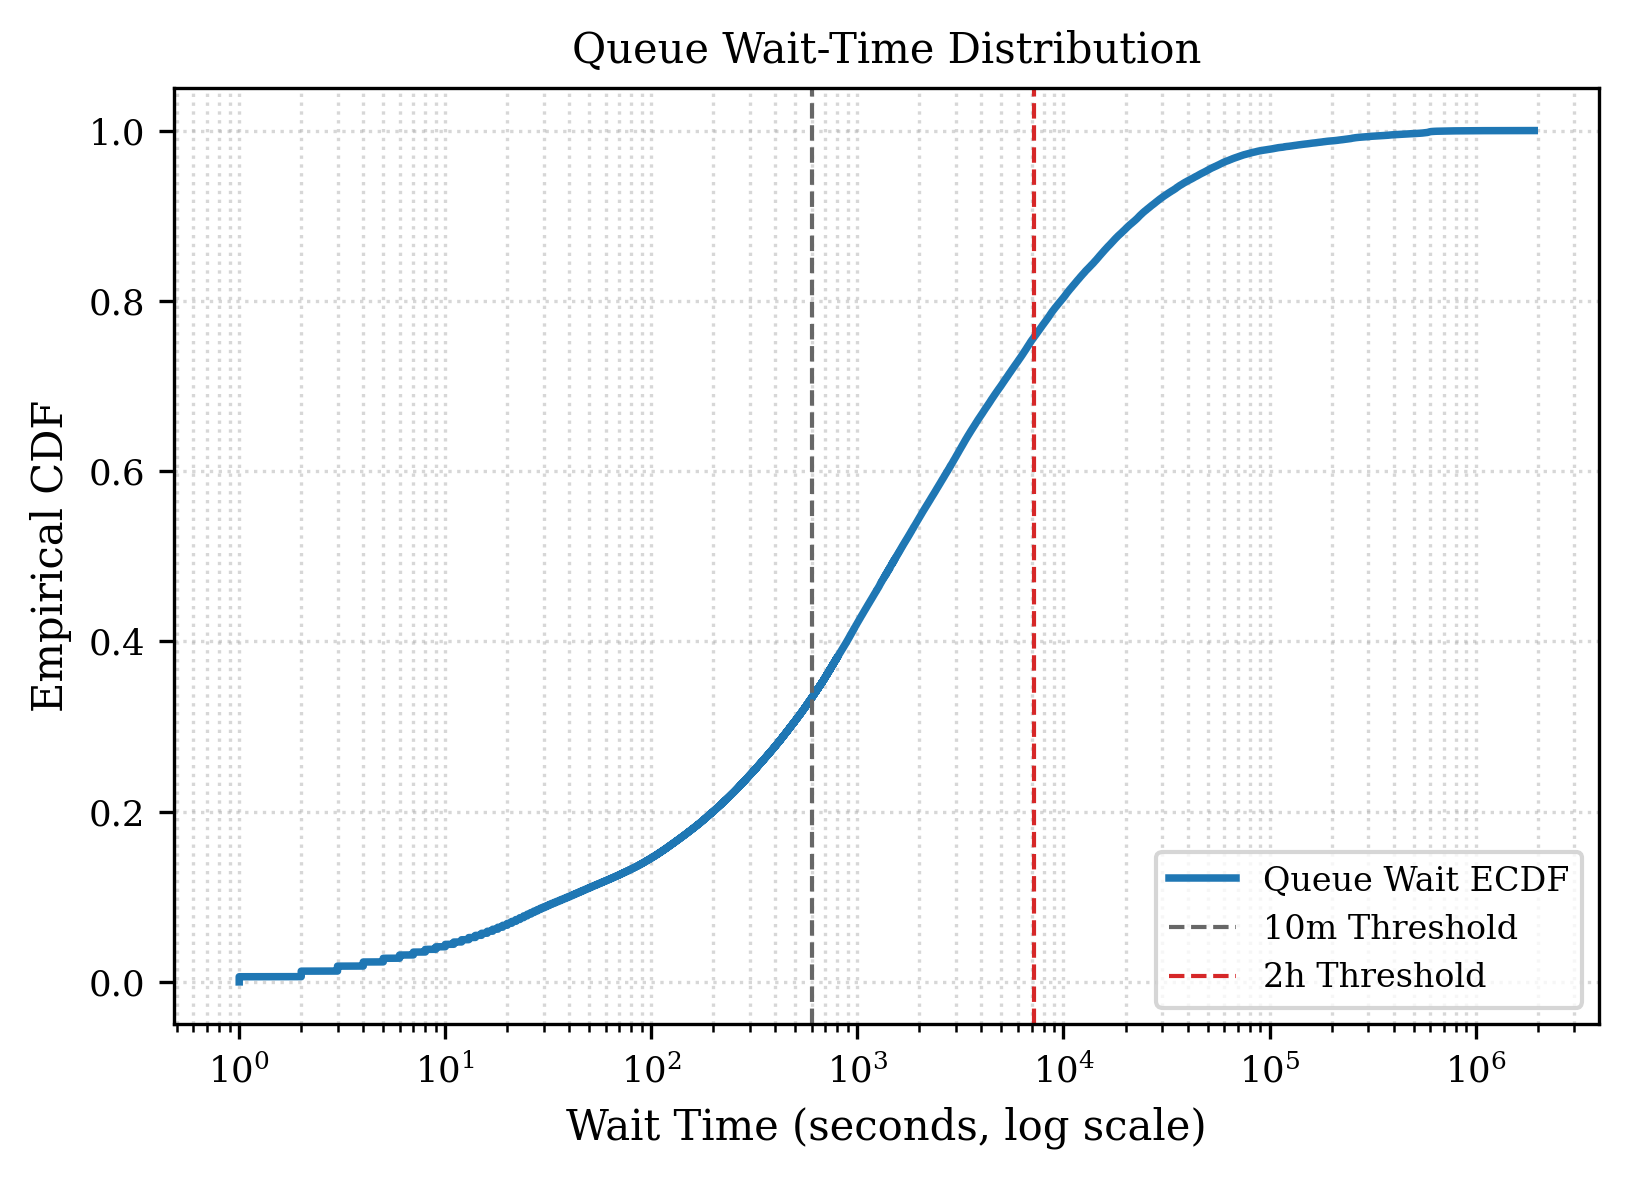

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4), dpi=300)

df_wait = (
    lf.select(pl.col("wait_s"))
    .drop_nulls()
    .filter(pl.col("wait_s") > 0)
    .collect()
)
wait_s = df_wait["wait_s"].to_numpy()
sorted_wait = np.sort(wait_s)
cdf = np.arange(1, len(sorted_wait) + 1) / len(sorted_wait)

ax.plot(sorted_wait, cdf, color=COLORS["primary"], linewidth=1.8, label="Queue Wait ECDF")
ax.set_xscale("log")

ax.axvline(600, color=COLORS["neutral"], linestyle="--", linewidth=1, label="10m Threshold")
ax.axvline(7200, color=COLORS["danger"], linestyle="--", linewidth=1, label="2h Threshold")

ax.set_xlabel("Wait Time (seconds, log scale)")
ax.set_ylabel("Empirical CDF")
ax.set_title("Queue Wait-Time Distribution")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("wait_time_distribution.pdf", bbox_inches="tight")
plt.show()

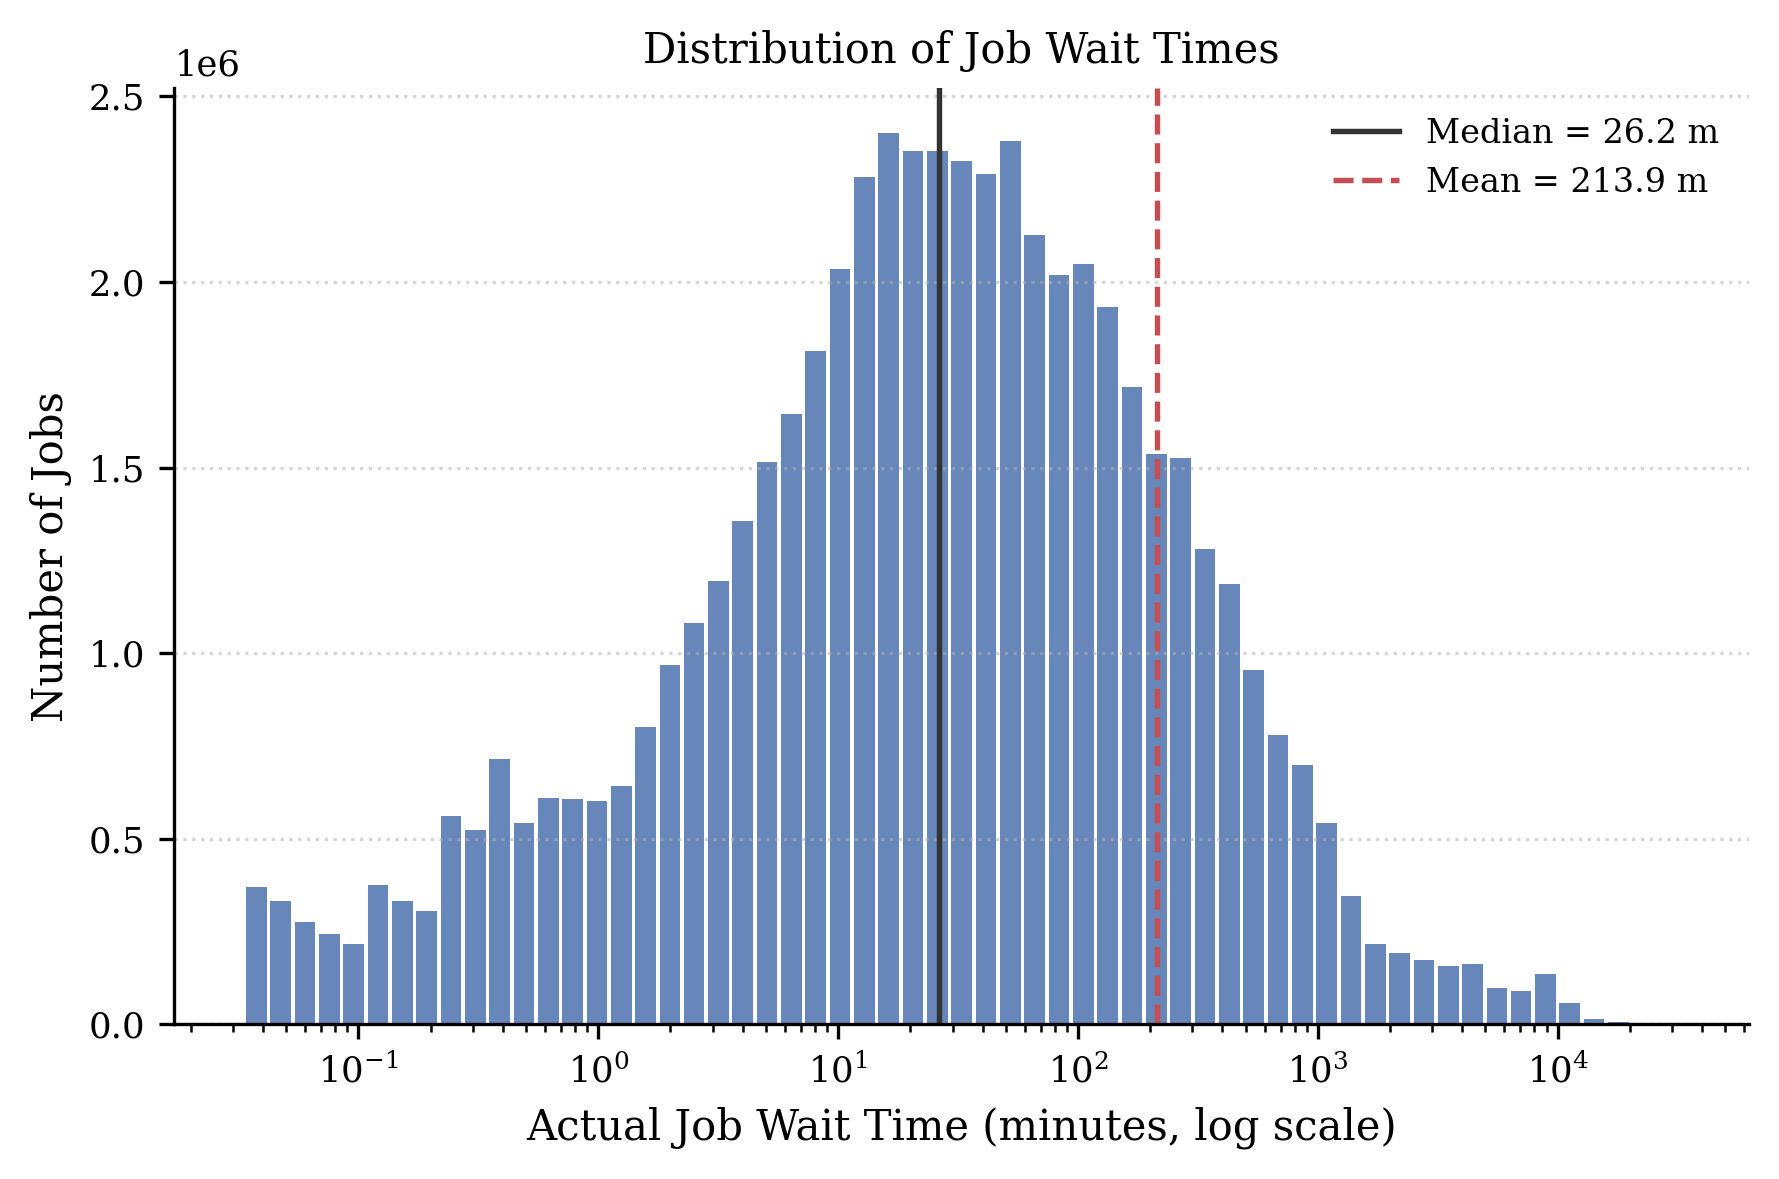

In [13]:
BASE_COLOR = "#4C72B0"

# df_wait = (
#     lf.select(pl.col("wait_s"))
#     .drop_nulls()
#     .filter(pl.col("wait_s") > 0)
#     .collect()
# )

# wait_s = df_wait["wait_s"].to_numpy()
# wt_min = wait_s[wait_s > 0] / 60.0 

df_all = lf.select(pl.col("wait_s")).collect()
total_jobs = len(df_all)
null_jobs= (df_all["wait_s"].is_null()).sum()
zero_jobs = (df_all["wait_s"] == 0).sum()
neg_jobs = (df_all["wait_s"] < 0).sum()

wt_pos_s = df_all.filter(pl.col("wait_s") > 1)["wait_s"].to_numpy()
wt_min = wt_pos_s / 60.0

mean_min = wt_min.mean()
median_min = np.median(wt_min)

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
bins = np.logspace(np.log10(max(wt_min.min(), 0.01)), np.log10(wt_min.max()), 60)
ax.hist(wt_min, bins=bins, color=BASE_COLOR, alpha=0.85, rwidth=0.85)
ax.set_xscale("log")
ax.axvline(median_min, color="#333333", linewidth=1.3, label=f"Median = {median_min:,.1f} m")
ax.axvline(mean_min, color="#C44E52", linestyle="--", linewidth=1.3, label=f"Mean = {mean_min:,.1f} m")

ax.set_xlabel("Actual Job Wait Time (minutes, log scale)")
ax.set_ylabel("Number of Jobs")
ax.set_title("Distribution of Job Wait Times")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("output/wait_time_distribution_skew.pdf", bbox_inches="tight")
plt.savefig("output/wait_time_distribution_skew.png", bbox_inches="tight", dpi=300)
plt.show()

In [21]:
print("Total jobs:", total_jobs)
print("Jobs with zero wait time:", zero_jobs)
print("Jobs with negative wait time:", neg_jobs)
print("Jobs with null wait time:", null_jobs)

Total jobs: 64025075
Jobs with zero wait time: 0
Jobs with negative wait time: 0
Jobs with null wait time: 7610397


In [24]:
null_breakdown = (
    lf.filter(pl.col("wait_s").is_null())
    .group_by(["JobStatus", "ExitCode", "ExitSignal"]) 
    .agg(count=pl.len())
    .with_columns(percentage=(pl.col("count") / 7_610_397) * 100)
    .sort("count", descending=True)
    .collect()
)

print(null_breakdown)

shape: (62, 5)
┌───────────┬──────────┬────────────┬─────────┬────────────┐
│ JobStatus ┆ ExitCode ┆ ExitSignal ┆ count   ┆ percentage │
│ ---       ┆ ---      ┆ ---        ┆ ---     ┆ ---        │
│ i64       ┆ i64      ┆ i64        ┆ u32     ┆ f64        │
╞═══════════╪══════════╪════════════╪═════════╪════════════╡
│ 3         ┆ null     ┆ null       ┆ 7170653 ┆ 94.221799  │
│ 4         ┆ 0        ┆ null       ┆ 397016  ┆ 5.216758   │
│ 4         ┆ 20       ┆ null       ┆ 12726   ┆ 0.167219   │
│ 4         ┆ 21       ┆ null       ┆ 11495   ┆ 0.151043   │
│ 4         ┆ 1        ┆ null       ┆ 5642    ┆ 0.074135   │
│ …         ┆ …        ┆ …          ┆ …       ┆ …          │
│ 4         ┆ 66       ┆ 15         ┆ 1       ┆ 0.000013   │
│ 4         ┆ 124      ┆ null       ┆ 1       ┆ 0.000013   │
│ 4         ┆ 2        ┆ null       ┆ 1       ┆ 0.000013   │
│ 4         ┆ 1        ┆ 9          ┆ 1       ┆ 0.000013   │
│ 4         ┆ 0        ┆ 7          ┆ 1       ┆ 0.000013   │
└────────

In [ ]:
short_wait_stats = (
    lf.filter((pl.col("wait_s") > 0) & (pl.col("wait_s") <= 60))
    .select(
        total_under_1min=pl.len(),
        sub_1s=(pl.col("wait_s") <= 1).sum(),
        sub_5s=((pl.col("wait_s") > 1) & (pl.col("wait_s") <= 5)).sum(),
        sub_10s=((pl.col("wait_s") > 5) & (pl.col("wait_s") <= 10)).sum(),
        sub_30s=((pl.col("wait_s") > 10) & (pl.col("wait_s") <= 30)).sum(),
        sub_60s=((pl.col("wait_s") > 30) & (pl.col("wait_s") <= 60)).sum(),
    )
    .collect()
)

print("Short Wait Time Granular Breakdown:")
print(short_wait_stats)

sub_1s_breakdown = (
    lf.filter((pl.col("wait_s") > 0) & (pl.col("wait_s") <= 1))
    .group_by(["JobStatus", "ExitCode"]) 
    .agg(count=pl.len())
    .sort("count", descending=True)
    .head(10)
    .collect()
)

print("\nSub-Second Job Attributes:")
print(sub_1s_breakdown)

Short Wait Time Granular Breakdown:
shape: (1, 6)
┌──────────────────┬────────┬─────────┬─────────┬─────────┬─────────┐
│ total_under_1min ┆ sub_1s ┆ sub_5s  ┆ sub_10s ┆ sub_30s ┆ sub_60s │
│ ---              ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ u32              ┆ u32    ┆ u32     ┆ u32     ┆ u32     ┆ u32     │
╞══════════════════╪════════╪═════════╪═════════╪═════════╪═════════╡
│ 6712673          ┆ 342160 ┆ 1221316 ┆ 922775  ┆ 2487846 ┆ 1738576 │
└──────────────────┴────────┴─────────┴─────────┴─────────┴─────────┘

Sub-Second Job Attributes:
shape: (10, 3)
┌───────────┬──────────┬────────┐
│ JobStatus ┆ ExitCode ┆ count  │
│ ---       ┆ ---      ┆ ---    │
│ i64       ┆ i64      ┆ u32    │
╞═══════════╪══════════╪════════╡
│ 4         ┆ 0        ┆ 302816 │
│ 4         ┆ 21       ┆ 16121  │
│ 4         ┆ 1        ┆ 7526   │
│ 4         ┆ 20       ┆ 4209   │
│ 3         ┆ null     ┆ 3482   │
│ 4         ┆ 127      ┆ 1833   │
│ 4         ┆ 88       ┆ 1689   │
│ 4      

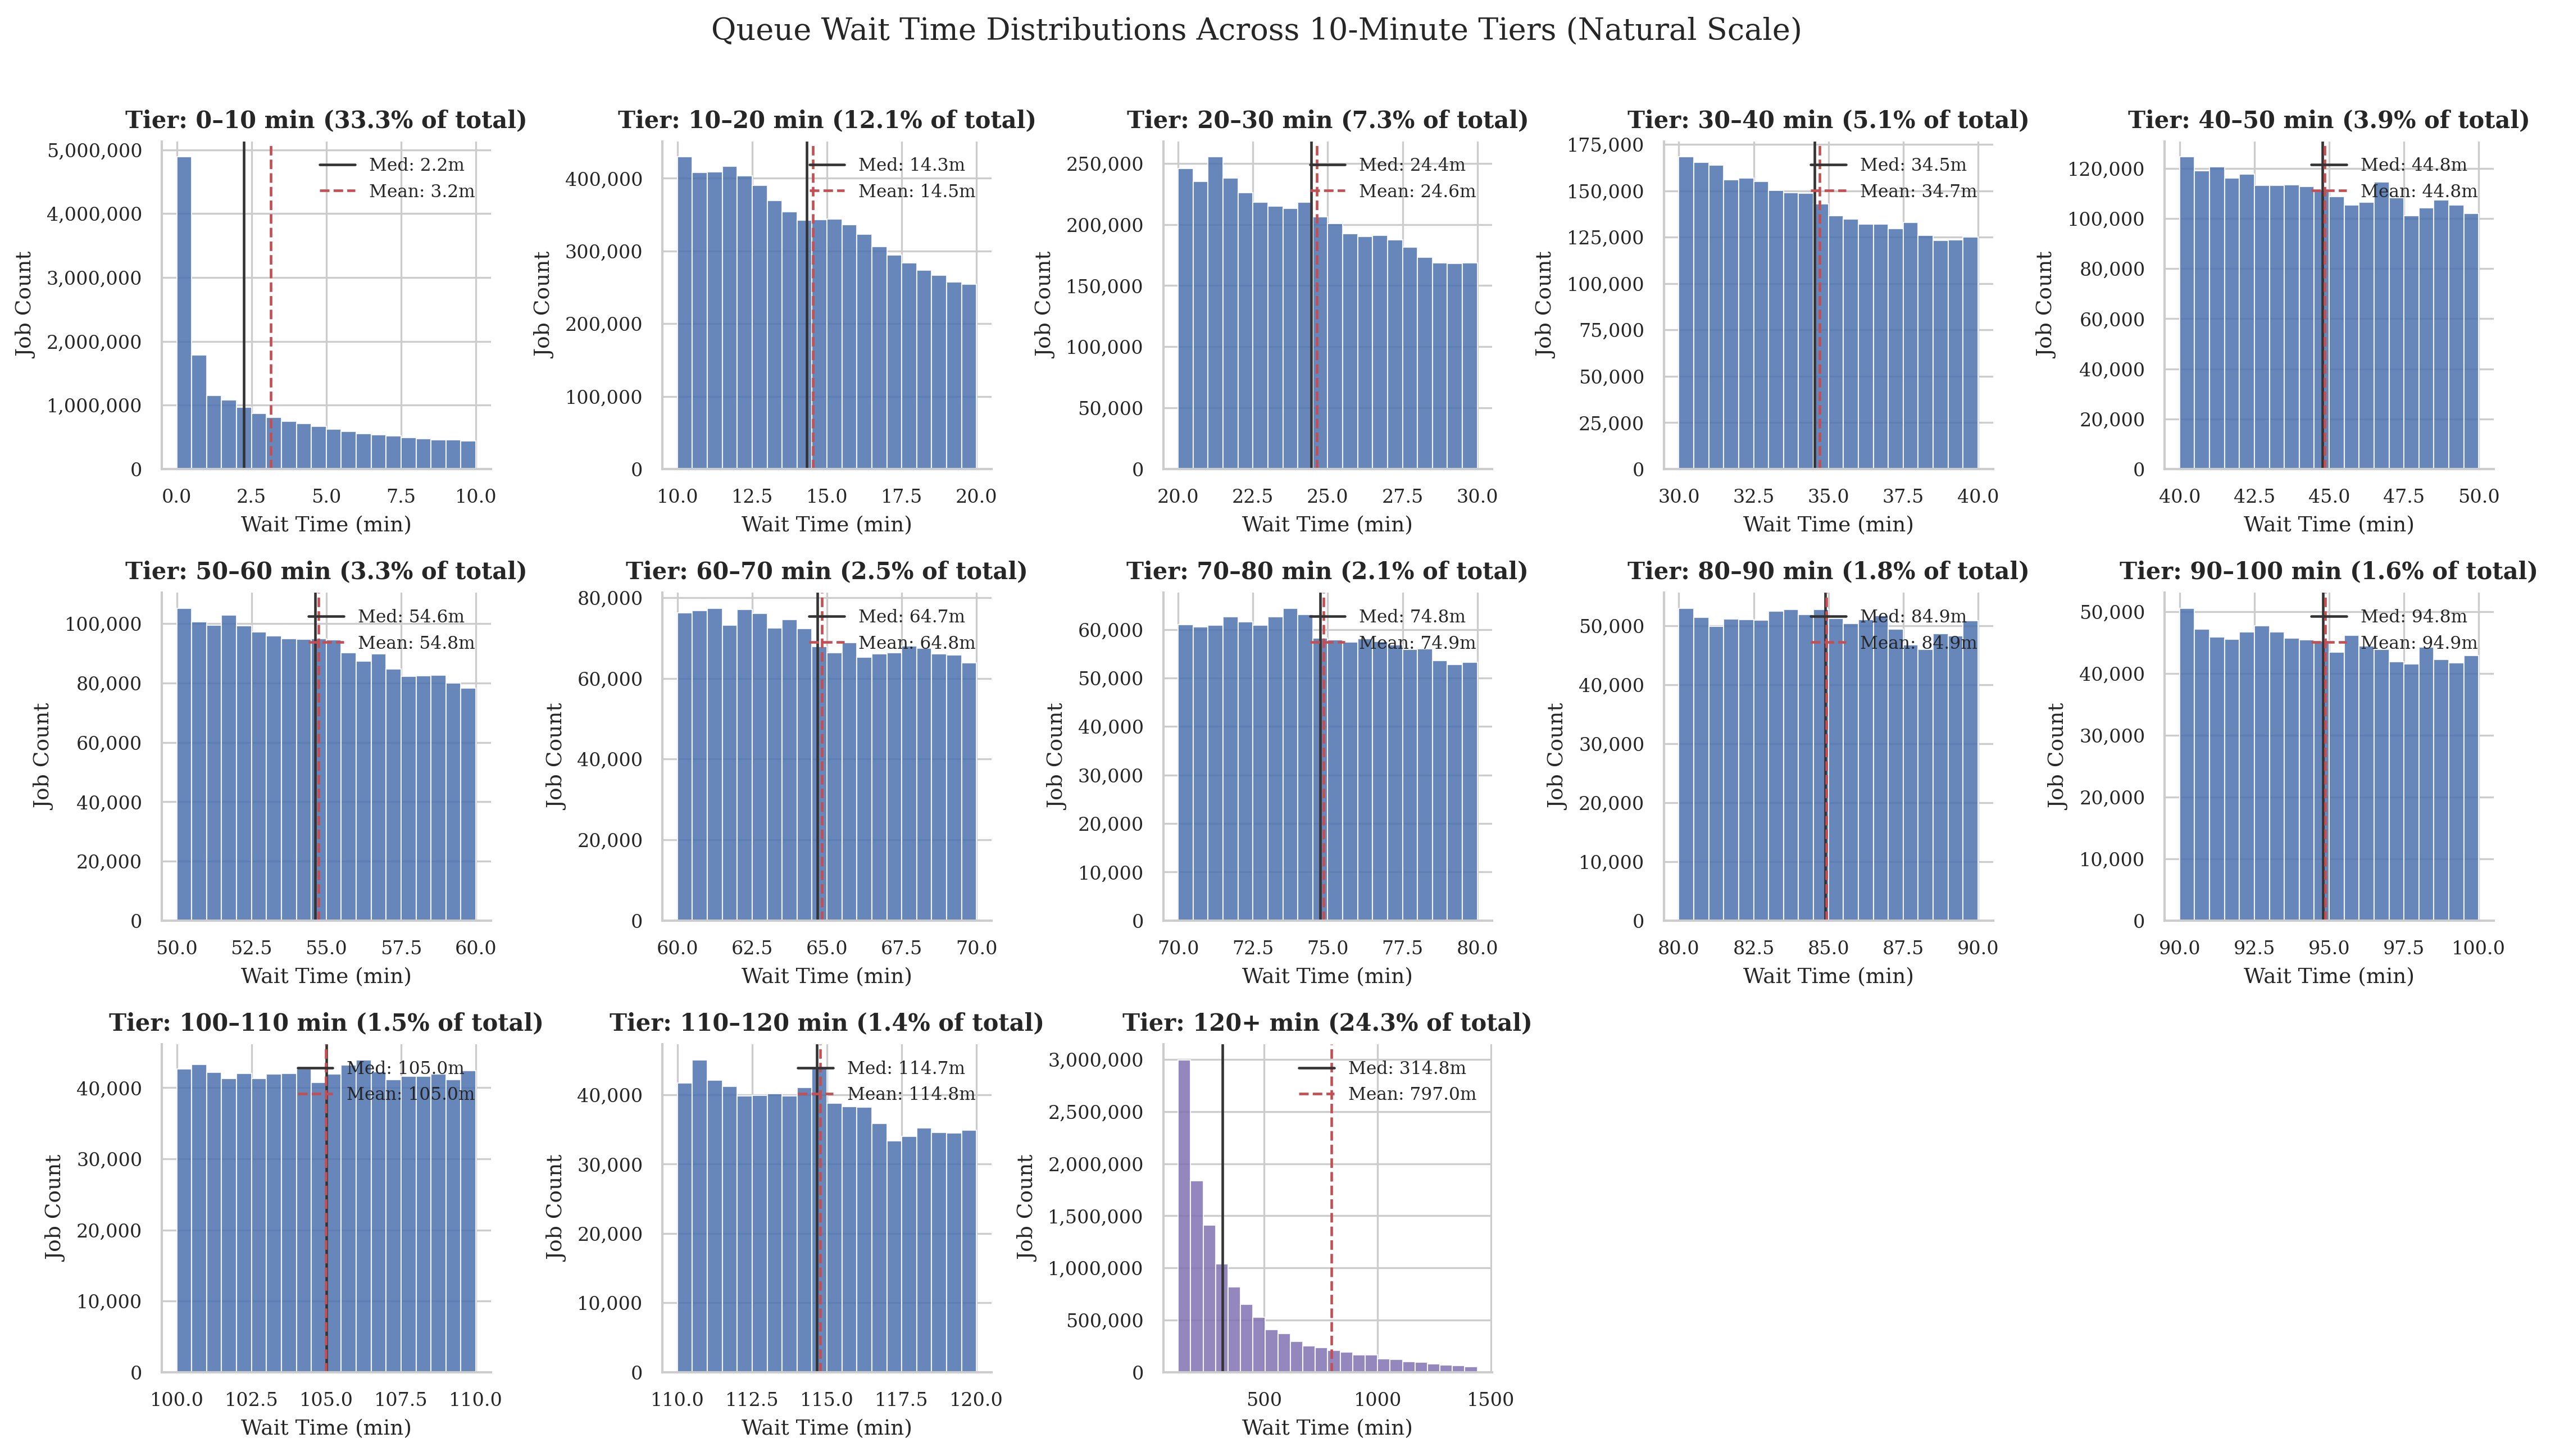

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

# Styling configuration
sns.set_theme(style="whitegrid", context="paper", font="serif")
plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

BASE_COLOR = "#4C72B0"
ACCENT_COLOR = "#C44E52"

# 1. Helper for Streaming Polars Data Selection
def sc(f):
    try:
        return f.collect(engine="streaming")
    except TypeError:
        return f.collect(streaming=True)

# 2. Extract Wait Times in Minutes
df_wait = sc(
    lf.filter(pl.col("wait_s").is_not_null() & (pl.col("wait_s") >= 0))
    .select((pl.col("wait_s") / 60.0).alias("wt_min"))
)
wt_min_arr = df_wait["wt_min"].to_numpy()
total_jobs = len(wt_min_arr)

# 3. Define the 13 Tiers
tier_bounds = [(i, i + 10) for i in range(0, 120, 10)]

# 4. Create Subplot Grid (3 rows x 5 columns = 15 axes, 13 used)
fig, axes = plt.subplots(3, 5, figsize=(15, 8.5), dpi=300)
axes = axes.flatten()

for idx, (start, end) in enumerate(tier_bounds):
    ax = axes[idx]
    # Filter data within the 10-minute window
    mask = (wt_min_arr >= start) & (wt_min_arr < end)
    sub_data = wt_min_arr[mask]
    n_jobs = len(sub_data)
    pct = (n_jobs / total_jobs) * 100.0 if total_jobs > 0 else 0.0

    if n_jobs > 0:
        mean_v = sub_data.mean()
        med_v = np.median(sub_data)

        # 20 uniform bins across the 10-minute window
        bins = np.linspace(start, end, 21)
        ax.hist(
            sub_data,
            bins=bins,
            color=BASE_COLOR,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.5,
        )

        # Add mean/median reference lines
        ax.axvline(
            med_v, color="#333333", linestyle="-", linewidth=1.1, label=f"Med: {med_v:.1f}m"
        )
        ax.axvline(
            mean_v, color=ACCENT_COLOR, linestyle="--", linewidth=1.1, label=f"Mean: {mean_v:.1f}m"
        )
        ax.legend(frameon=False, fontsize=7.5, loc="upper right")

    ax.set_title(f"Tier: {start}–{end} min ({pct:.1f}% of total)", fontweight="bold")
    ax.set_xlabel("Wait Time (min)")
    ax.set_ylabel("Job Count")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# 5. Final Subplot: 120+ Minutes Tier
ax_tail = axes[12]
tail_data = wt_min_arr[wt_min_arr >= 120]
n_tail = len(tail_data)
pct_tail = (n_tail / total_jobs) * 100.0 if total_jobs > 0 else 0.0

if n_tail > 0:
    mean_tail = tail_data.mean()
    med_tail = np.median(tail_data)

    # Upper bound clipped at 99th percentile for visual clarity
    max_cap = min(np.percentile(tail_data, 99), 1440)  # max 24 hours
    bins_tail = np.linspace(120, max_cap, 25)

    ax_tail.hist(
        tail_data,
        bins=bins_tail,
        color="#8172B3",
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
    )

    ax_tail.axvline(
        med_tail, color="#333333", linestyle="-", linewidth=1.1, label=f"Med: {med_tail:.1f}m"
    )
    ax_tail.axvline(
        mean_tail, color=ACCENT_COLOR, linestyle="--", linewidth=1.1, label=f"Mean: {mean_tail:.1f}m"
    )
    ax_tail.legend(frameon=False, fontsize=7.5, loc="upper right")

ax_tail.set_title(f"Tier: 120+ min ({pct_tail:.1f}% of total)", fontweight="bold")
ax_tail.set_xlabel("Wait Time (min)")
ax_tail.set_ylabel("Job Count")
ax_tail.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax_tail.spines["top"].set_visible(False)
ax_tail.spines["right"].set_visible(False)

# 6. Hide unused subplots (indexes 13 and 14)
for idx in [13, 14]:
    fig.delaxes(axes[idx])

plt.suptitle(
    "Queue Wait Time Distributions Across 10-Minute Tiers (Natural Scale)",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()

plt.savefig("output/wait_time_tier_subplots.pdf", bbox_inches="tight")
plt.savefig("output/wait_time_tier_subplots.png", bbox_inches="tight", dpi=300)
plt.show()

### Exit code analysis

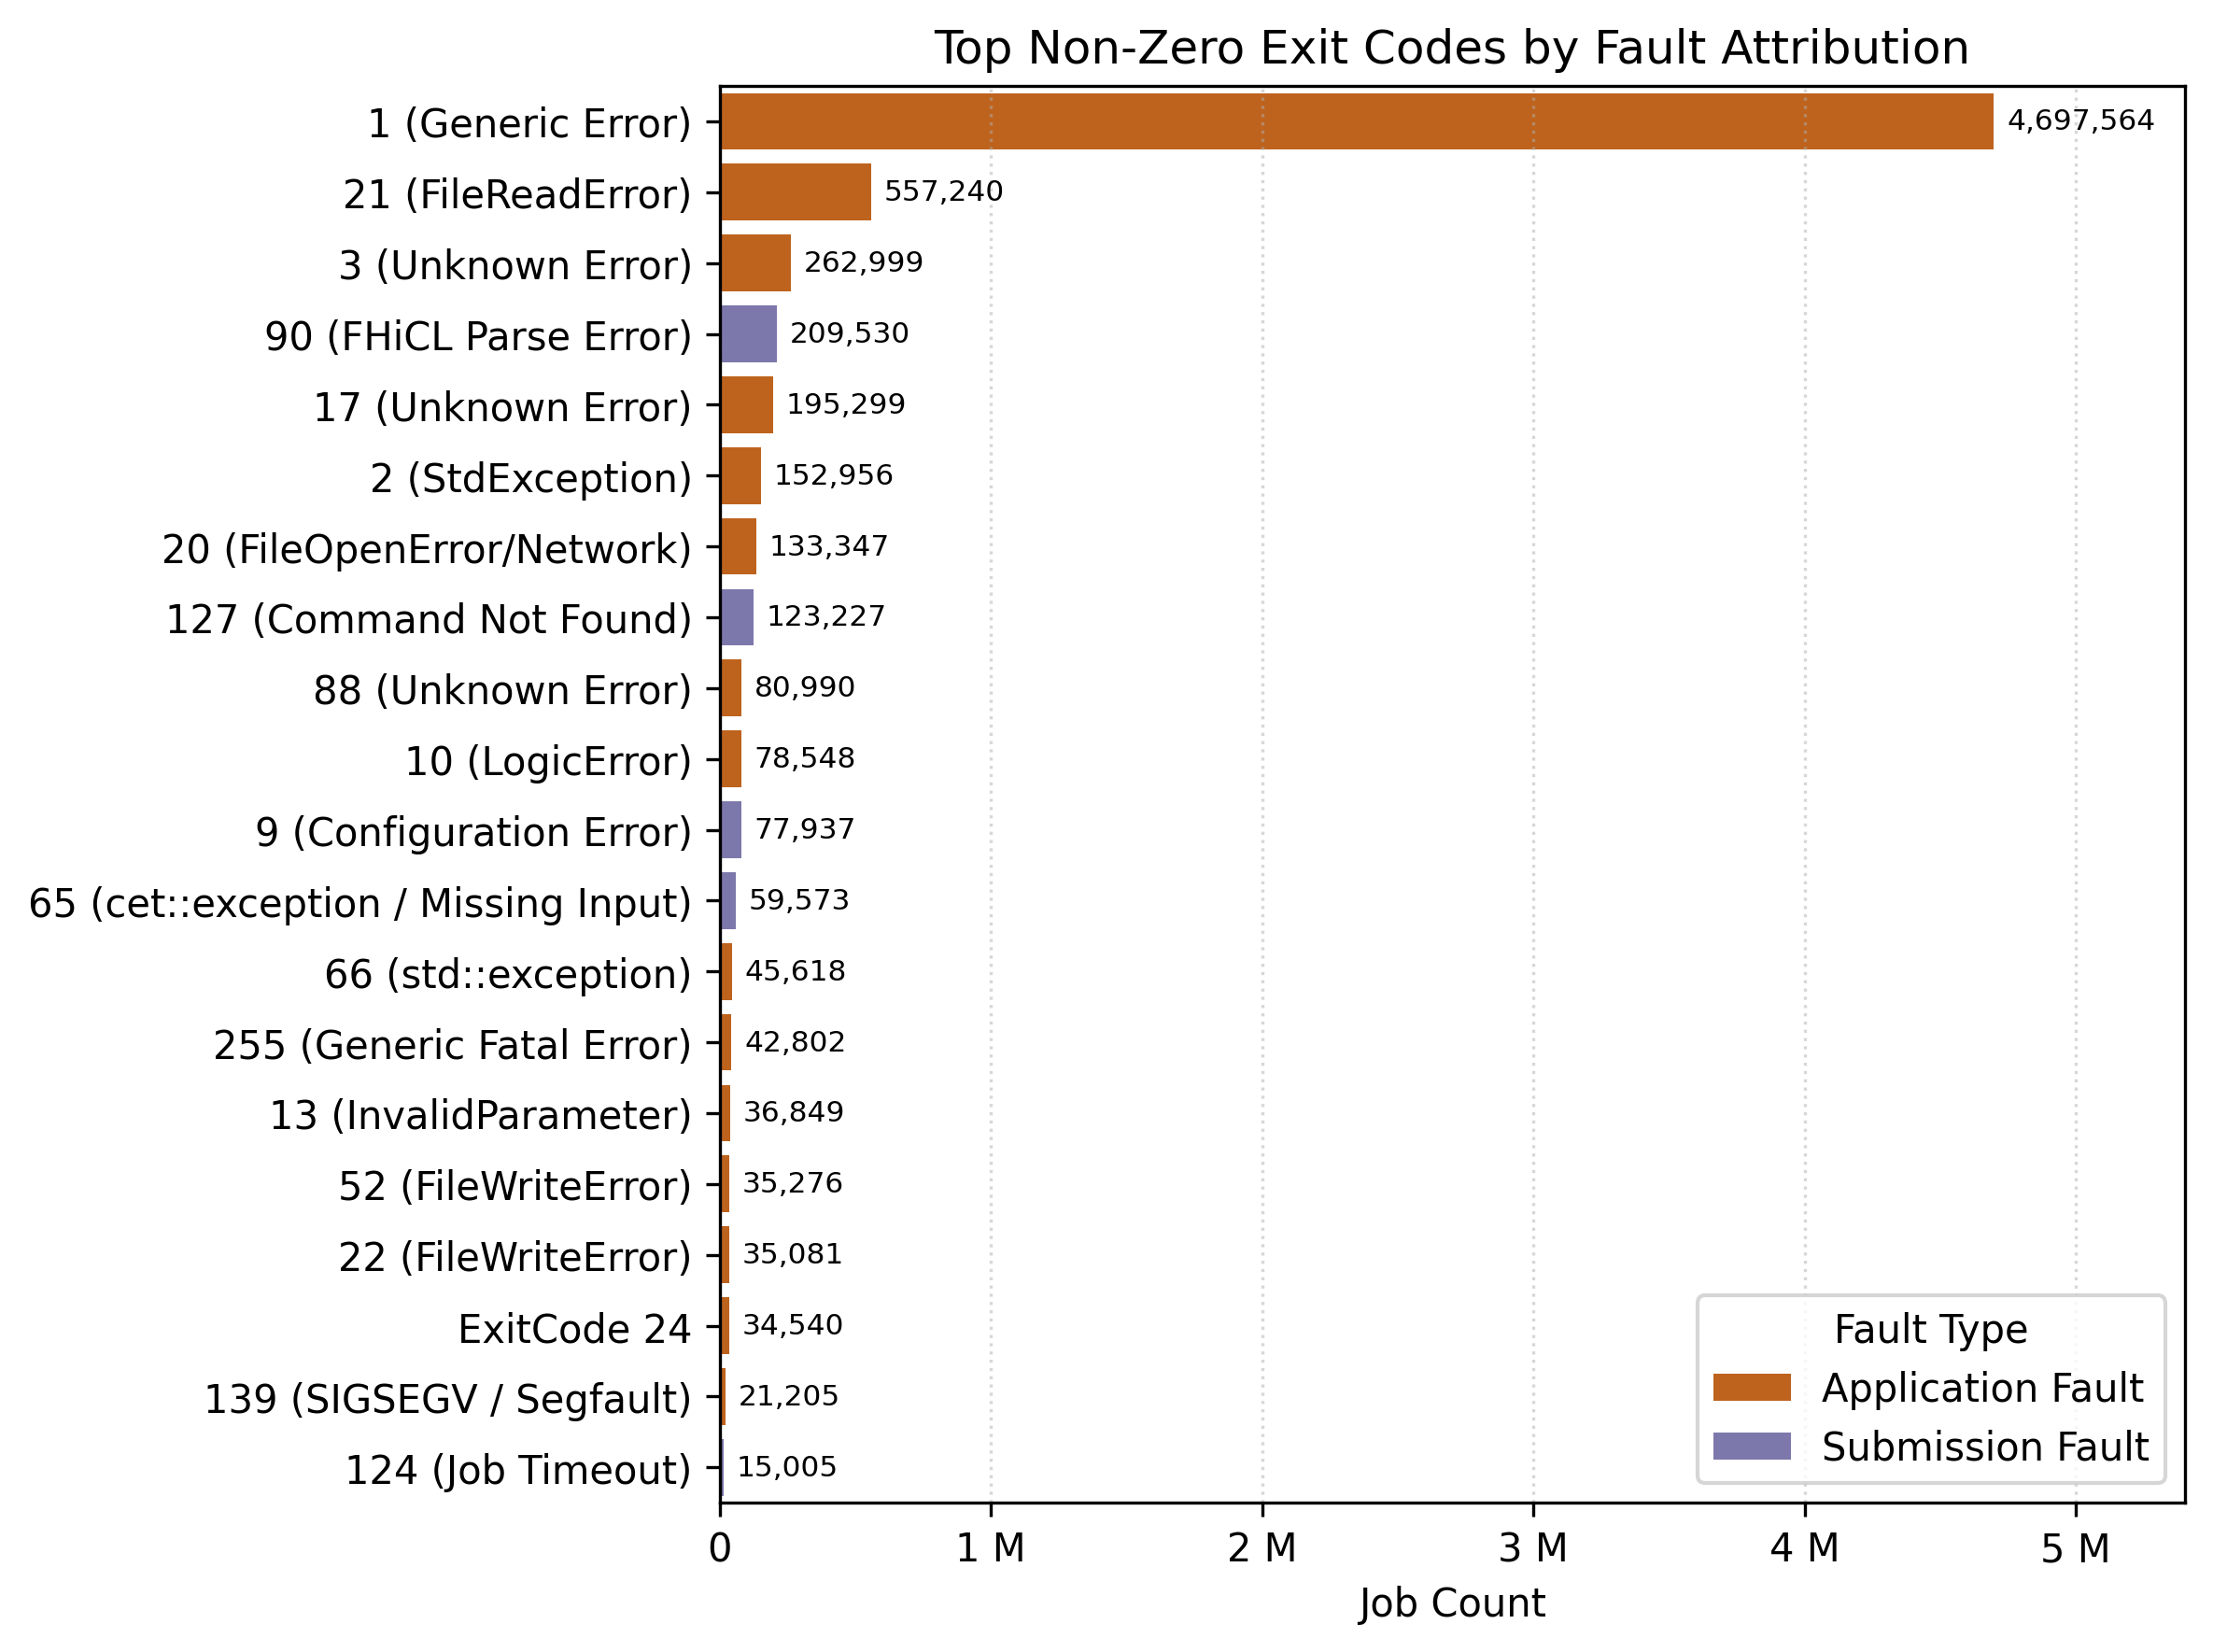

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

# README Exit Code Description Mapping
labels = {
    "1": "1 (Generic Error)",
    "2": "2 (StdException)",
    "3": "3 (Unknown Error)",
    "4": "4 (BadAlloc)",
    "5": "5 (BadExceptionType)",
    "6": "6 (ProductNotFound)",
    "9": "9 (Configuration Error)",
    "10": "10 (LogicError)",
    "11": "11 (UnimplementedFeature)",
    "12": "12 (InvalidReference)",
    "13": "13 (InvalidParameter)",
    "14": "14 (NullPointerError)",
    "15": "15 (EventTimeout)",
    "16": "16 (DataCorruption)",
    "17": "17 (Unknown Error)",
    "20": "20 (FileOpenError/Network)",
    "21": "21 (FileReadError)",
    "22": "22 (FileWriteError)",
    "52": "52 (FileWriteError)",
    "65": "65 (cet::exception / Missing Input)",
    "66": "66 (std::exception)",
    "68": "68 (std::bad_alloc)",
    "88": "88 (Unknown Error)",
    "90": "90 (FHiCL Parse Error)",
    "91": "91 (FHiCL Parameter Error)",
    "124": "124 (Job Timeout)",
    "126": "126 (Command Cannot Execute)",
    "127": "127 (Command Not Found)",
    "129": "129 (SIGHUP / Lost Session)",
    "130": "130 (SIGINT / Interrupted)",
    "131": "131 (SIGQUIT)",
    "134": "134 (SIGABRT / Self-Abort)",
    "137": "137 (SIGKILL / OOM Timeout)",
    "139": "139 (SIGSEGV / Segfault)",
    "143": "143 (SIGTERM / Node Drain)",
    "255": "255 (Generic Fatal Error)",
}

# Code-table classification rules
EXIT_SUB = {9, 65, 90, 91, 124, 126, 127, 130, 131, 137}
EXIT_HW = {129, 143}


def get_fault_category(code):
    if code in EXIT_HW:
        return "Hardware Fault"
    elif code in EXIT_SUB:
        return "Submission Fault"
    return "Application Fault"


FAULT_PALETTE = {
    "Application Fault": "#d95f02",  # Warm Orange / Red
    "Submission Fault": "#7570b3",   # Purple / Blue
    "Hardware Fault": "#1b9e77",     # Teal / Green
}

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

df_ec = (
    lf.filter((pl.col("ExitCode") != 0) & pl.col("ExitCode").is_not_null())
    .group_by("ExitCode")
    .len()
    .sort("len", descending=True)
    .head(20)
    .collect()
    .to_pandas()
)

df_ec["Label"] = df_ec["ExitCode"].map(
    lambda x: labels.get(str(x), f"ExitCode {x}")
)
df_ec["Fault Category"] = df_ec["ExitCode"].map(get_fault_category)

sns.barplot(
    data=df_ec,
    y="Label",
    x="len",
    hue="Fault Category",
    dodge=False,
    palette=FAULT_PALETTE,
    ax=ax,
)

max_val = df_ec["len"].max()
for i, count in enumerate(df_ec["len"]):
    ax.text(
        count + (max_val * 0.01),
        i,
        f"{count:,}",
        va="center",
        fontsize=7.5,
    )

ax.set_xlim(0, max_val * 1.15)
ax.set_xlabel("Job Count")
ax.set_ylabel("")
ax.set_title("Top Non-Zero Exit Codes by Fault Attribution")
ax.grid(True, axis="x", linestyle=":", alpha=0.5)
ax.xaxis.set_major_formatter(ticker.EngFormatter())

# Clean legend positioning
ax.legend(title="Fault Type", loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig("output/exit_codes_distribution.pdf", bbox_inches="tight")
plt.show()

### Failure correlations

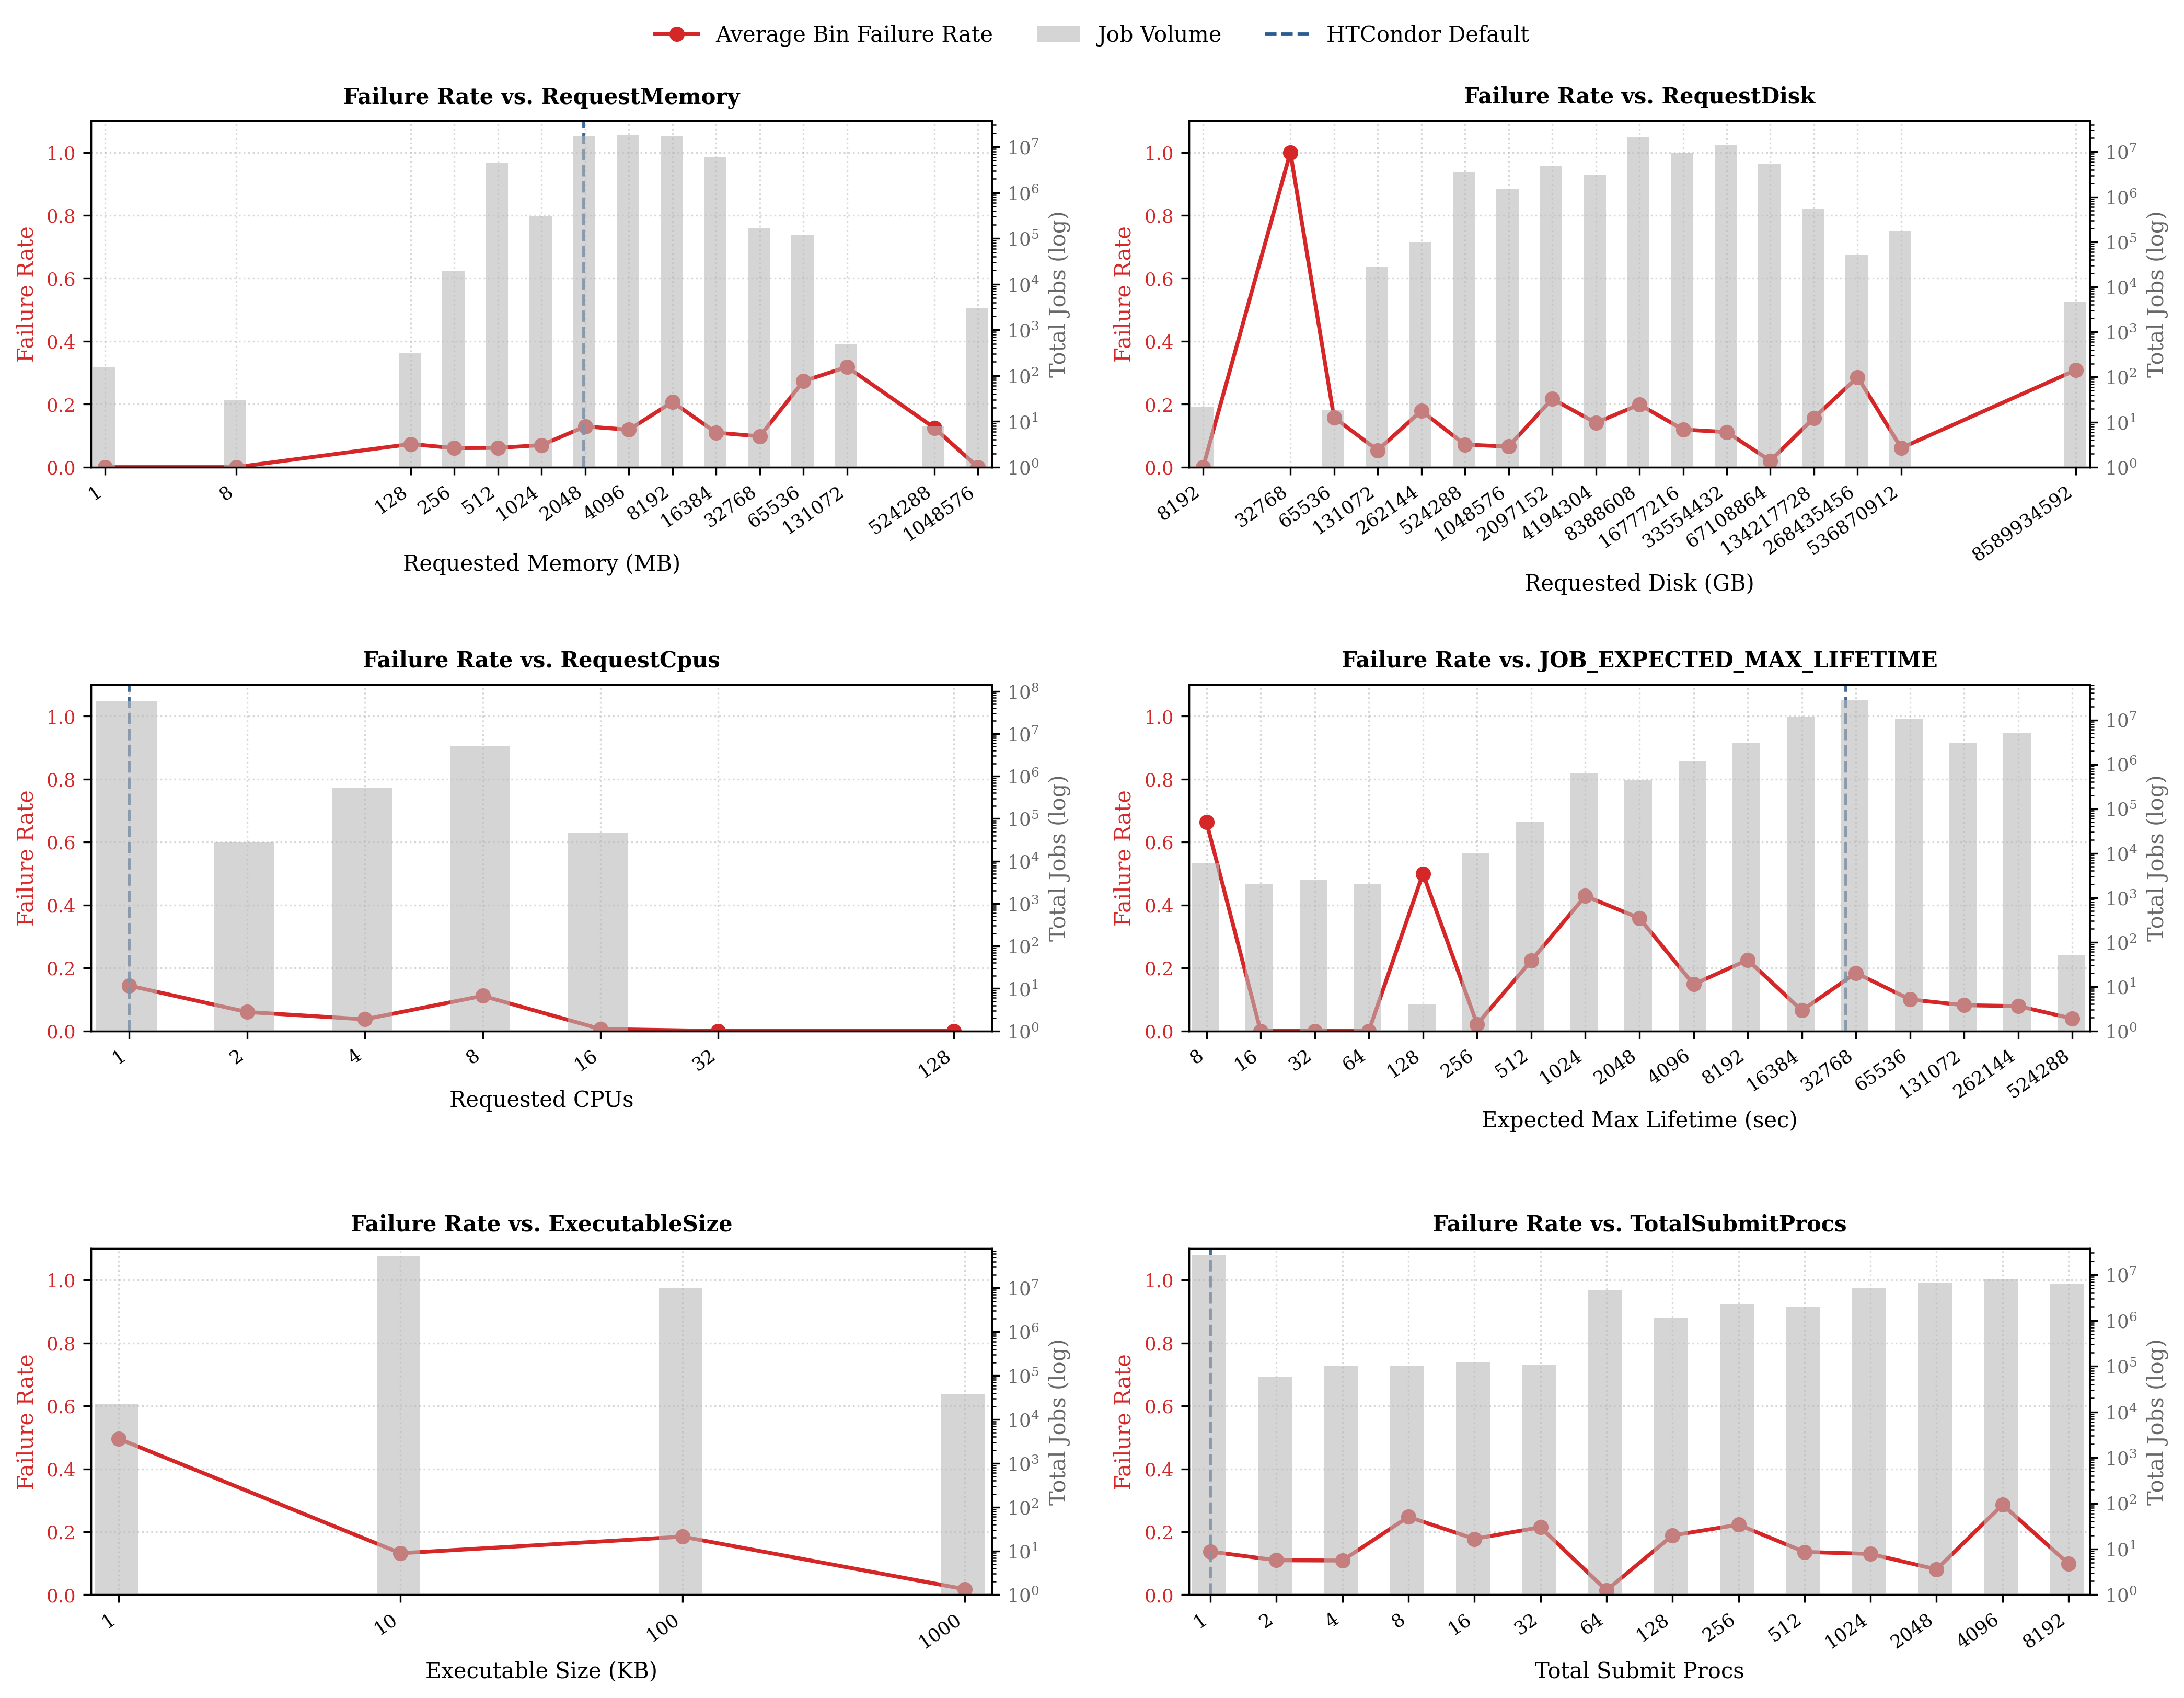

In [12]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

FEATURE_CONFIGS = [
    {
        "col": "RequestMemory",
        "mode": "log2",
        "default": 2000, 
        "label": "Requested Memory (MB)",
        "default_label": "Default (2000 MB)",
        "base": 2,
    },
    {
        "col": "RequestDisk",
        "mode": "log2",
        "label": "Requested Disk (GB)",
        "default": 10, 
        "default_label": "Default (10 GB)",
        "base": 2,
    },
    {
        "col": "RequestCpus",
        "mode": "log2",
        "label": "Requested CPUs",
        "default": 1.0,
        "default_label": "Default (1.0)",
        "base": 2,
    },
    {
        "col": "JOB_EXPECTED_MAX_LIFETIME",
        "mode": "log2",
        "default": 28800.0,
        "default_label": "Default (8 hours)",
        "label": "Expected Max Lifetime (sec)",
        "base": 2,
    },
    {
        "col": "ExecutableSize",
        "mode": "log10",
        "default": None,
        "default_label": "Default (None)",
        "label": "Executable Size (KB)",
        "base": 10,
    },
    {
        "col": "TotalSubmitProcs",
        "mode": "log2",
        "unit_scale": 1.0,
        "default": 1.0,
        "default_label": "Default (1.0)",
        "label": "Total Submit Procs",
        "base": 2,
    },
]

def format_tick_val(x, pos):
    """Formats tick labels: rounds floats cleanly and strips trailing zeros."""
    if abs(x - round(x)) < 1e-6:
        return f"{int(round(x))}"
    elif abs(x) < 1:
        return f"{x:.3f}".rstrip("0").rstrip(".")
    else:
        return f"{x:.2f}".rstrip("0").rstrip(".")

def extract_binned_feature_df(
    lf, col_name, mode, unit_scale=1.0, min_count=500
):
    """Aggregates job counts and failure rates per feature bin using Polars."""
    e = pl.col(col_name).cast(pl.Float64, strict=False)

    if mode == "log2":
        b_expr = e.log(2).round()
    elif mode == "log10":
        b_expr = e.log10().round()
    elif mode == "raw":
        b_expr = e.clip(0, 32).round()

    df = (
        lf.filter(e > 0)
        .with_columns(b_expr.alias("bin"))
        .group_by("bin")
        .agg(
            [
                pl.len().alias("count"),
                pl.col("Failed").mean().alias("fail_rate"),
            ]
        )
        # .filter(pl.col("count") >= min_count)
        .sort("bin")
        .collect()
        .to_pandas()
    )

    if mode == "log2":
        df["x_val"] = (2.0 ** df["bin"]) * unit_scale
    elif mode == "log10":
        df["x_val"] = (10.0 ** df["bin"]) * unit_scale
    elif mode == "raw":
        df["x_val"] = df["bin"] * unit_scale

    return df

fig, axes = plt.subplots(3, 2, figsize=(14, 11), dpi=300)
axes = axes.flatten()

for i, cfg in enumerate(FEATURE_CONFIGS):
    col = cfg["col"]
    ax = axes[i]

    if col not in lf.collect_schema().names():
        ax.set_visible(False)
        continue

    df_binned = extract_binned_feature_df(lf, col, cfg["mode"])
    if df_binned.empty:
        ax.set_visible(False)
        continue

    ax_twin = ax.twinx()

    x_vals = df_binned["x_val"].values
    bar_widths = x_vals * 0.35 if cfg["base"] is not None else 0.4

    # Secondary Y-Axis: Job Volume (Background Bars)
    ax_twin.bar(
        x_vals,
        df_binned["count"],
        width=bar_widths,
        color=COLORS["volume_fill"],
        alpha=0.6,
    )
    ax_twin.set_yscale("log")
    ax_twin.set_ylim(bottom=1)
    ax_twin.set_ylabel("Total Jobs (log)", color=COLORS["neutral"])
    ax_twin.tick_params(axis="y", labelcolor=COLORS["neutral"])
    ax_twin.grid(False)

    # Primary Y-Axis: Failure Rate Line
    ax.plot(
        x_vals,
        df_binned["fail_rate"],
        marker="o",
        color=COLORS["danger"],
        linewidth=1.8,
    )

    # Annotate DUNE/HTCondor Default Line
    if cfg.get("default") is not None:
        ax.axvline(
            x=cfg["default"],
            color=COLORS["default_line"],
            linestyle="--",
            linewidth=1.4,
            alpha=0.9,
            zorder=5,
        )

    # Axis Scaling & Formatting
    if cfg["base"] is not None:
        ax.set_xscale("log", base=cfg["base"])
        valid_ticks = np.sort(df_binned["x_val"].unique())
        ax.set_xticks(valid_ticks)
        ax.set_xlim(valid_ticks[0] * 0.8, valid_ticks[-1] * 1.25)
        ax.set_ylim(0, 1.1)
    else:
        ax.set_xscale("linear")
        valid_ticks = np.sort(df_binned["x_val"].unique())
        ax.set_xticks(valid_ticks[:: max(1, len(valid_ticks) // 8)])

    ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(format_tick_val))
    ax.xaxis.set_minor_locator(ticker.NullLocator())

    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    ax.set_xlabel(cfg["label"])
    ax.set_ylabel("Failure Rate", color=COLORS["danger"])
    ax.tick_params(axis="y", labelcolor=COLORS["danger"])
    ax.set_title(f"Failure Rate vs. {col}", fontweight="bold", pad=8)
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

# Shared Global Legend at top of figure
legend_elements = [
    Line2D(
        [0],
        [0],
        color=COLORS["danger"],
        marker="o",
        linewidth=1.8,
        label="Average Bin Failure Rate",
    ),
    Patch(facecolor=COLORS["volume_fill"], alpha=0.6, label="Job Volume"),
    Line2D(
        [0],
        [0],
        color=COLORS["default_line"],
        linestyle="--",
        linewidth=1.4,
        label="HTCondor Default",
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=3,
    frameon=False,
    fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.8, w_pad=2.2)
plt.savefig("output/failure_vs_features_corr.pdf", bbox_inches="tight")
plt.show()